# Classification Model for Defective Parts in Production
## AutomaParts S.p.A. - Transverse Arm Assembly Line

---

# Technical Report

## 1. Preliminary Analysis

### Business Context

AutomaParts S.p.A. is a tier-1 automotive supplier that manufactures precision mechanical components for steering and suspension systems. Part quality is a critical requirement: a defective part reaching the final assembly can cause machine downtime, high rework costs, or OEM recalls, with significant financial and reputational impacts.

### Classification Problem

For each manufactured part, dimensional measurements (diameter, length, flatness), process parameters (temperature, torque, vibration, cycle time), surface roughness information, and a visual inspection score are recorded. At the end of the cycle, a binary label `defect_label` is assigned (0=conforming, 1=defective).

The objective is to train a supervised machine learning model that automatically predicts the presence of a defect based on the measurements recorded on the production line. The expected output is a decision-support tool: automatic rejection, additional inspection, or clearance for production.

### Main Challenges

- **Class imbalance**: defective parts account for approximately 22% of the dataset. Accuracy alone is not a reliable metric: a model that always predicted "conforming" would reach 78% accuracy without detecting any defect. Metrics such as F1-score and ROC-AUC are required.
- **Asymmetric error costs**: a false negative (defective classified as conforming) has a much higher operational cost than a false positive (conforming part stopped for additional inspection). The classification threshold must account for this ratio.
- **Heterogeneous data**: the dataset contains continuous numerical variables, categorical identifiers, and a timestamp. Consistent pre-processing is needed before training.
- **Interpretability**: process engineers need to understand which variables affect defect rates in order to intervene on root causes.

## 2. Technical Choices

### Selected Models

Three algorithms with complementary characteristics were chosen:

| Model | Rationale | Advantage | Limitation |
|---|---|---|---|
| Decision Tree | interpretable baseline | rules readable by operators | tends to overfit on noisy data |
| Random Forest | robust ensemble | reduces variance of individual trees | less interpretable |
| Logistic Regression | probabilistic linear baseline | calibrated probabilistic output | assumes linear separability between classes |

### Handling Missing Values

- numerical variables: imputation with the median, chosen for robustness to outliers
- categorical variables: imputation with the mode

### Feature Engineering

- `production_timestamp` is decomposed into `hour_of_day`, `day_of_week` and `month`, used as proxies for the work shift, which can influence process quality
- from the `material_batch` code, the production week (`batch_week`) is extracted to capture seasonal variations in raw materials
- `line_id`, `station_id` and `operator_id` are treated as ordinal numerical variables

### Scaling and Evaluation

- StandardScaler on numerical variables (especially required for logistic regression)
- stratified 80/20 split to preserve class proportions in train and test sets
- 5-fold cross-validation to verify stability of performance estimates
- main metrics: ROC-AUC, F1-score on the defective class and recall of defective parts

---

# NOTEBOOK - Model Development

## Section 0 - Library Imports

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Scikit-learn: pre-processing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Scikit-learn: models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Scikit-learn: metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

RANDOM_STATE = 0  # reproducibility seed

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Section 1 - Dataset Loading

In [2]:
# Path to CSV file relative to notebook location
# DATA_PATH = 'datasets/parts_production_data.csv'

# Path to CSV file on the web (load directly from URL)
DATA_PATH = 'https://raw.githubusercontent.com/Profession-AI/progetti-ml/refs/heads/main/Modello%20di%20classificazione%20di%20pezzi%20difettosi%20in%20produzione/parts_production_data.csv'

df = pd.read_csv(DATA_PATH)
print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset loaded: 3000 rows x 16 columns


,part_id,production_timestamp,line_id,station_id,operator_id,measure_diam_mm,measure_length_mm,flatness_mm,torque_Nm,surface_roughness_Ra,temp_process_C,vibration_level,cycle_time_s,material_batch,visual_inspection_score,defect_label
0,1,2024-06-13 17:42:45,2,1,5,15.582,34.100,34.813,318.147,33.620,72.543,0.093695,146.532,MB-2024W24-L02-575,0.602019,1
1,2,2024-07-26 10:36:48,9,14,4,42.377,30.260,36.116,379.256,23.610,82.438,0.957213,167.319,MB-2024W30-L09-100,0.092746,0
2,3,2025-12-08 17:35:40,6,20,5,25.141,52.082,36.588,347.408,44.468,116.188,0.704572,109.165,MB-2025W50-L06-297,0.227898,0
3,4,2024-12-09 12:56:36,4,4,7,35.427,44.593,27.404,183.803,20.679,144.932,0.648035,221.826,MB-2024W50-L04-747,0.171139,0
4,5,2025-09-08 15:54:15,8,13,5,22.618,40.710,24.220,477.164,45.055,95.174,0.655439,179.126,MB-2025W37-L08-470,0.914548,1


In [3]:
# Overview of data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   part_id                  3000 non-null   int64  
 1   production_timestamp     3000 non-null   object 
 2   line_id                  3000 non-null   int64  
 3   station_id               3000 non-null   int64  
 4   operator_id              3000 non-null   int64  
 5   measure_diam_mm          3000 non-null   float64
 6   measure_length_mm        3000 non-null   float64
 7   flatness_mm              3000 non-null   float64
 8   torque_Nm                3000 non-null   float64
 9   surface_roughness_Ra     3000 non-null   float64
 10  temp_process_C           3000 non-null   float64
 11  vibration_level          3000 non-null   float64
 12  cycle_time_s             3000 non-null   float64
 13  material_batch           3000 non-null   object 
 14  visual_inspection_score 

In [4]:
# Descriptive statistics (scale, range, outliers)
df.describe().round(3)

,part_id,line_id,station_id,operator_id,measure_diam_mm,measure_length_mm,flatness_mm,torque_Nm,surface_roughness_Ra,temp_process_C,vibration_level,cycle_time_s,visual_inspection_score,defect_label
count,3000.00,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000
mean,1500.50,5.548,10.632,5.497,30.261,49.708,29.824,302.045,29.888,110.732,0.496,200.483,0.498,0.224
std,866.17,2.825,5.808,2.869,11.407,11.536,5.798,115.859,11.639,23.245,0.286,57.752,0.286,0.417
min,1.00,1.000,1.000,1.000,10.014,30.005,20.003,100.085,10.000,70.006,0.000,100.094,0.000,0.000
25%,750.75,3.000,5.750,3.000,20.643,39.667,24.744,201.608,19.955,90.625,0.254,149.544,0.249,0.000
50%,1500.50,6.000,11.000,6.000,30.277,49.451,29.795,303.522,29.670,111.266,0.495,200.840,0.510,0.000
75%,2250.25,8.000,16.000,8.000,39.928,59.595,34.846,400.808,40.269,131.194,0.745,250.877,0.744,0.000
max,3000.00,10.000,20.000,10.000,49.997,69.986,39.994,499.619,49.959,149.968,1.000,299.995,1.000,1.000


## Section 2 - Exploratory Data Analysis (EDA)

Exploratory analysis is used to understand the structure of the dataset before building the model: distribution of the target variable, presence of class imbalances, relationships between features and defect rate.

### 2.1 Distribution of the Target Variable

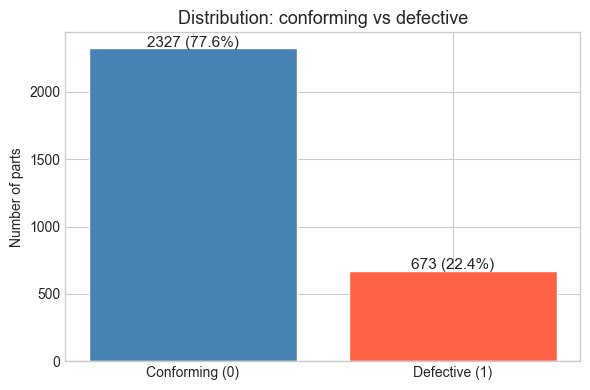

In [5]:
# Count conforming (0) and defective (1) parts.
# With heavy imbalance, accuracy alone is misleading:
# a model that always predicts "0" would achieve high accuracy without detecting any defect.
target_counts = df['defect_label'].value_counts()
target_pct    = df['defect_label'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Conforming (0)', 'Defective (1)'], target_counts,
       color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Distribution: conforming vs defective', fontsize=13)
ax.set_ylabel('Number of parts')
for i, v in enumerate(target_counts):
    ax.text(i, v + 10, f'{v} ({target_pct.iloc[i]:.1f}%)', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

The dataset contains 2,327 conforming parts (77.6%) and 673 defective parts (22.4%). The imbalance is moderate but significant: a ratio of approximately 3.5:1 between classes. For this reason, `class_weight='balanced'` is used during training and metrics such as F1-score and ROC-AUC are used during evaluation, which do not mask performance on the minority class the way accuracy alone would.

### 2.2 Defect Rate by Production Line

Aggregating defect rates by line allows identifying which lines produce a proportionally higher number of defective parts. This analysis has direct value for production managers: lines with the highest rate are primary candidates for maintenance checks, tooling inspections, or operational condition reviews.

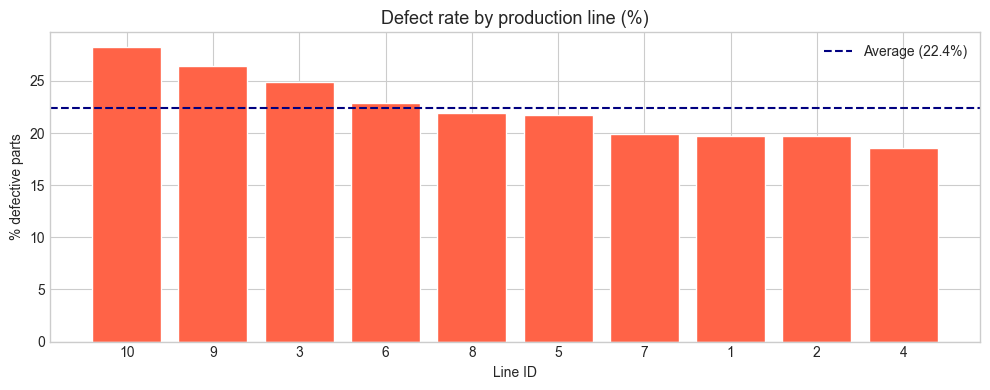

         defect_rate  n_parts  defect_pct
line_id                                  
10          0.282528      269       28.25
9           0.264798      321       26.48
3           0.249201      313       24.92
6           0.228840      319       22.88
8           0.219436      319       21.94
5           0.217822      303       21.78
7           0.198697      307       19.87
1           0.197183      284       19.72
2           0.197080      274       19.71
4           0.185567      291       18.56


In [6]:
# The mean of defect_label per line equals the % of defective parts per line.
# Useful for production managers: identifies the most critical lines.
defect_by_line = (
    df.groupby('line_id')['defect_label']
      .agg(['mean', 'count'])
      .rename(columns={'mean': 'defect_rate', 'count': 'n_parts'})
      .sort_values('defect_rate', ascending=False)
)
defect_by_line['defect_pct'] = (defect_by_line['defect_rate'] * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(defect_by_line.index.astype(str), defect_by_line['defect_pct'],
       color='tomato', edgecolor='white')
ax.axhline(defect_by_line['defect_pct'].mean(), color='navy', linestyle='--',
           label=f'Average ({defect_by_line["defect_pct"].mean():.1f}%)')
ax.set_title('Defect rate by production line (%)', fontsize=13)
ax.set_xlabel('Line ID')
ax.set_ylabel('% defective parts')
ax.legend()
plt.tight_layout()
plt.show()

print(defect_by_line.to_string())

The defect rate ranges from a minimum of 18.6% on line 4 to a maximum of 28.3% on line 10, a difference of nearly 10 percentage points. Lines 9 (26.5%) and 10 (28.3%) are the most critical and would merit a dedicated analysis of operational conditions: tooling state, maintenance frequency, assigned operators. This type of per-line analysis is one of the most useful outputs for AutomaParts management, independent of the machine learning model.

### 2.3 Distribution of Numerical Variables by Class

Side-by-side boxplots show whether there is visual separation between conforming and defective parts for each feature. If the two boxplots overlap almost entirely, that variable alone discriminates little between the two classes. If instead the medians or ranges are clearly distinct, that feature is potentially informative for the model.

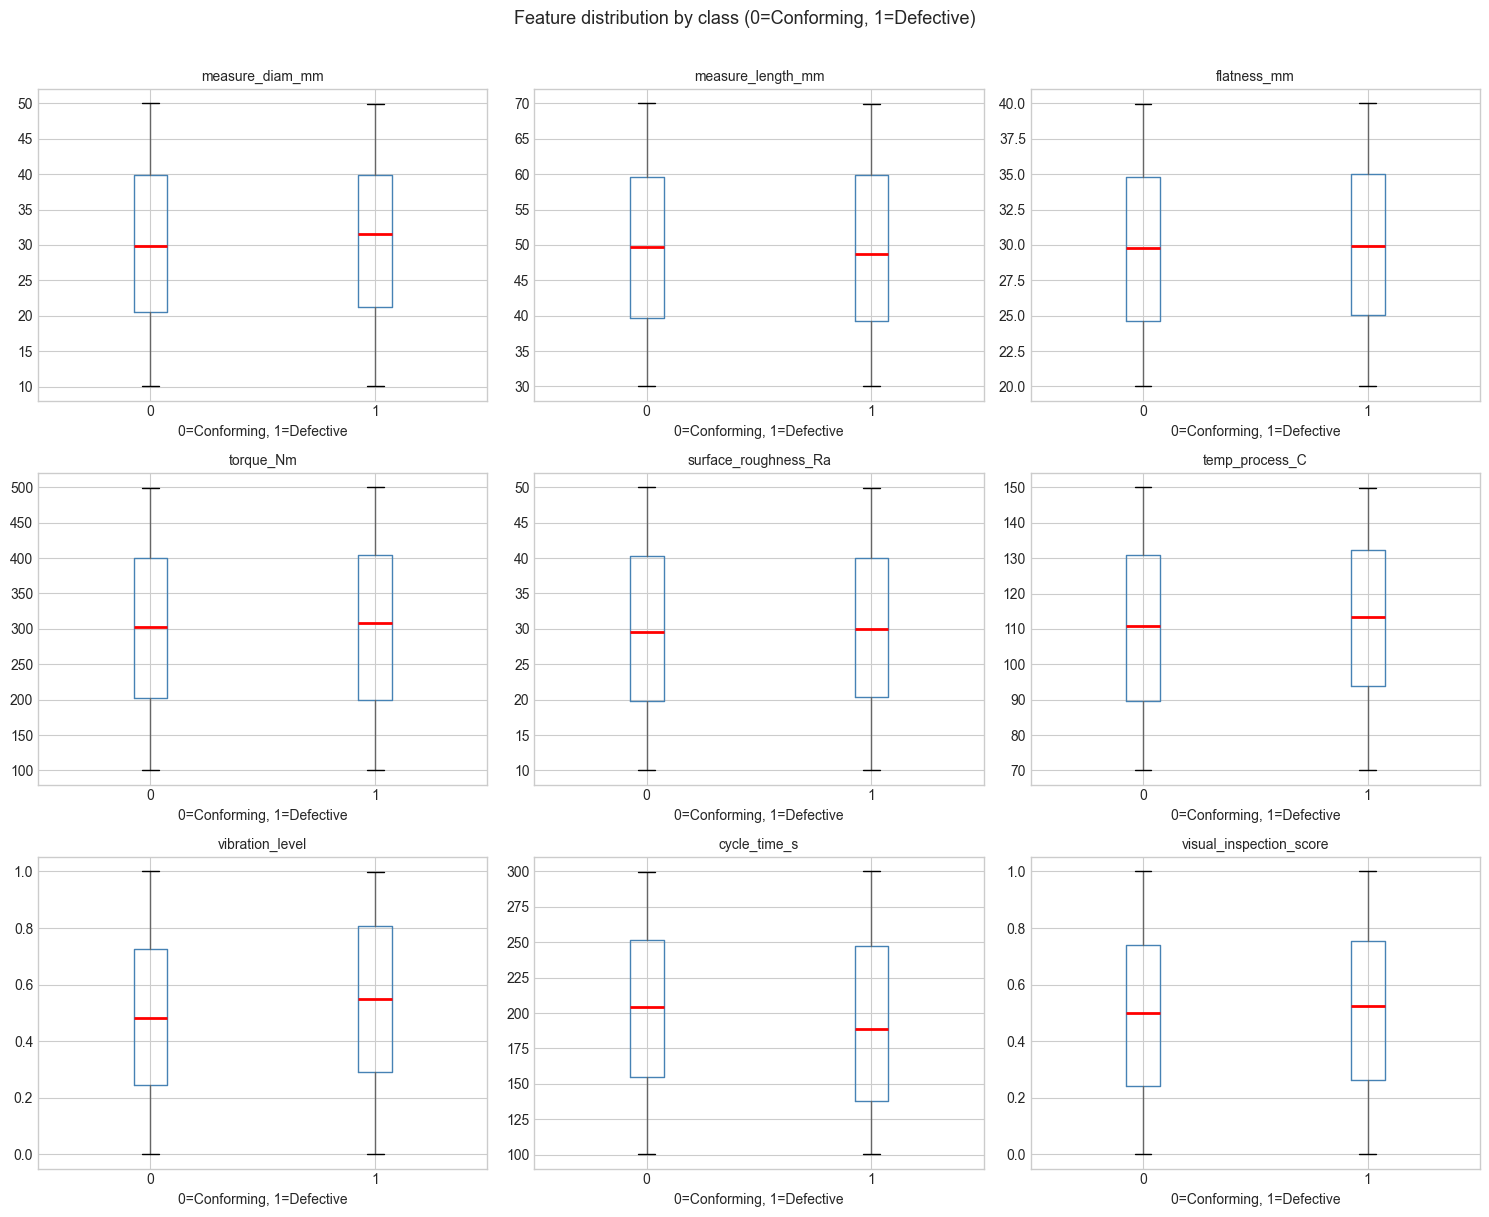

In [7]:
numeric_features = [
    'measure_diam_mm', 'measure_length_mm', 'flatness_mm',
    'torque_Nm', 'surface_roughness_Ra', 'temp_process_C',
    'vibration_level', 'cycle_time_s', 'visual_inspection_score'
]
numeric_features = [c for c in numeric_features if c in df.columns]

n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    df.boxplot(column=feat, by='defect_label', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('0=Conforming, 1=Defective')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature distribution by class (0=Conforming, 1=Defective)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The boxplots show that the distributions of the two classes overlap almost completely across all features. The most visible difference is in `cycle_time_s`: defective parts tend to have a slightly lower cycle time (approximately 193 seconds on average vs. 202 seconds for conforming parts), which could indicate processes executed too quickly. `vibration_level` also shows a slight difference (0.53 vs. 0.49 for conforming parts). For all other features the distributions are practically identical. This widespread overlap is an early signal that separating the two classes will not be straightforward.

### 2.4 Correlation Matrix

Pearson correlation measures the linear relationship between each feature and the target variable. High absolute values indicate that a variable alone can help separate the two classes. Values close to 0 do not rule out usefulness in combination with other features, but signal that no strong linear relationships exist.

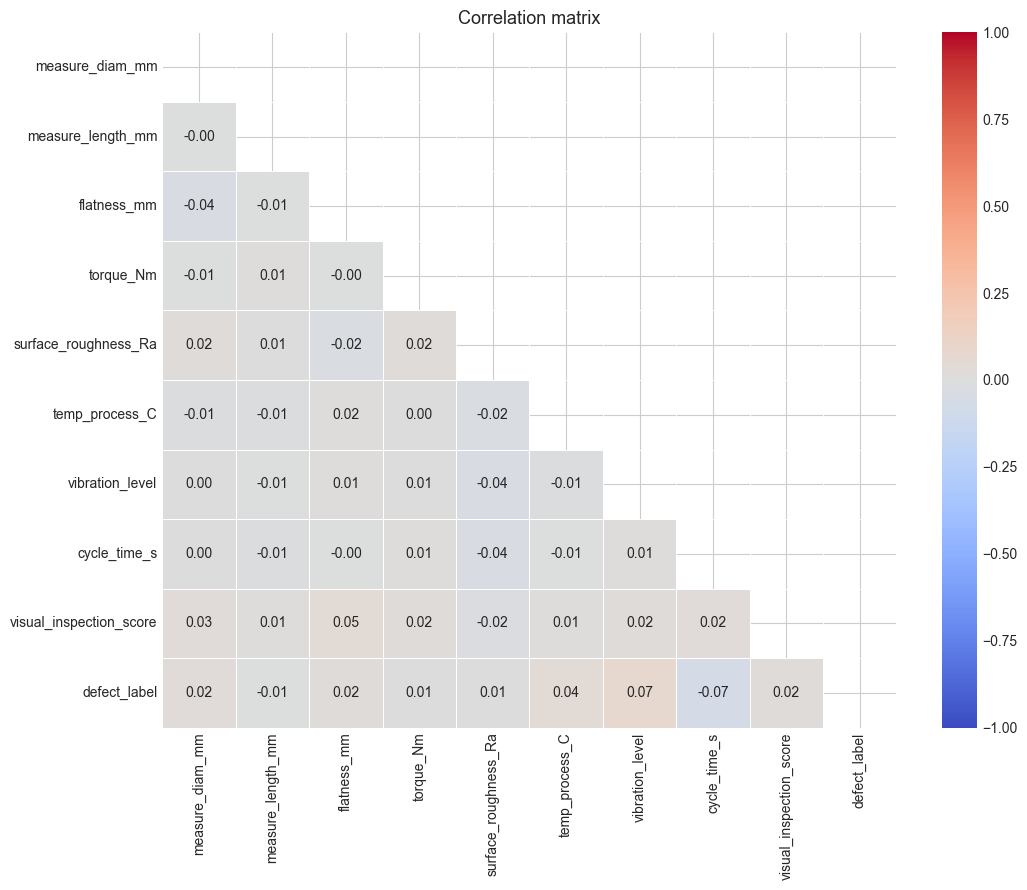


Correlation with defect_label (by absolute value):
vibration_level            0.071021
cycle_time_s               0.065991
temp_process_C             0.039249
measure_diam_mm            0.023777
flatness_mm                0.019362
visual_inspection_score    0.016767
torque_Nm                  0.007083
measure_length_mm          0.006231
surface_roughness_Ra       0.005292
Name: defect_label, dtype: float64


In [8]:
# Pearson measures the linear relationship between variables.
# High absolute correlation with defect_label = potentially useful feature.
corr_cols   = numeric_features + ['defect_label']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation matrix', fontsize=13)
plt.tight_layout()
plt.show()

print('\nCorrelation with defect_label (by absolute value):')
print(corr_matrix['defect_label'].drop('defect_label').abs().sort_values(ascending=False))

Correlations with `defect_label` are all very low: the highest is `vibration_level` at 0.07, followed by `cycle_time_s` (0.07) and `temp_process_C` (0.04). The pure dimensional measurements (`measure_length_mm`, `surface_roughness_Ra`, `torque_Nm`) are essentially uncorrelated with defect rate (values < 0.01). This is an important signal: no single feature has a strong linear relationship with the target. Linear models such as Logistic Regression will therefore likely struggle, and even non-linear models will have limited performance margins starting from these signals.

## Section 3 - Data Cleaning and Missing Value Handling

### 3.1 Missing Values

In [9]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing values': missing, '% of total': missing_pct})
missing_df = missing_df[missing_df['Missing values'] > 0].sort_values('% of total', ascending=False)

if missing_df.empty:
    print('No missing values found.')
else:
    print('Columns with missing values:')
    print(missing_df)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(missing_df.index, missing_df['% of total'], color='coral', edgecolor='white')
    ax.axvline(x=30, color='red', linestyle='--', label='30% threshold')
    ax.set_title('Percentage of missing values per column', fontsize=12)
    ax.set_xlabel('% missing')
    ax.legend()
    plt.tight_layout()
    plt.show()

No missing values found.


### 3.2 Duplicate Rows

In [10]:
n_dup = df.duplicated().sum()
print(f'Duplicate rows: {n_dup}')
if n_dup > 0:
    df = df.drop_duplicates()
    print(f'Remaining rows: {len(df)}')

Duplicate rows: 0


### 3.3 Outlier Analysis (IQR Method)

An outlier is a value outside the range $[Q1 - 1.5 \times IQR,\ Q3 + 1.5 \times IQR]$. In an industrial context, anomalous measurements are often associated with defects, so the adopted strategy is to retain them in the dataset: removing them could cause the model to lose information about precisely the conditions that generate defects.

In [11]:
print('Outlier analysis (IQR):\n')
rows = []
for col in numeric_features:
    if col not in df.columns:
        continue
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    rows.append({'Feature': col, 'N outliers': n_out, '%': round(n_out/len(df)*100, 2)})

print(pd.DataFrame(rows).sort_values('N outliers', ascending=False).to_string(index=False))

Outlier analysis (IQR):

                Feature  N outliers   %
        measure_diam_mm           0 0.0
      measure_length_mm           0 0.0
            flatness_mm           0 0.0
              torque_Nm           0 0.0
   surface_roughness_Ra           0 0.0
         temp_process_C           0 0.0
        vibration_level           0 0.0
           cycle_time_s           0 0.0
visual_inspection_score           0 0.0


The result of zero outliers across all features is unusual for real industrial data, where anomalous measurements are common and often directly associated with defects. Descriptive statistics show uniform ranges and symmetric distributions for all variables, suggesting the dataset may have been synthetically generated or pre-processed in advance. This may partly explain the low correlations with defect rate: in real data, out-of-tolerance measurements are often the most discriminating signals, and these appear to be absent here.

## Section 4 - Feature Preparation (Feature Engineering)

### 4.1 Temporal Features
We extract hour of day and day of week as proxies for the work shift.
Different shifts = different operators, different conditions = possible influence on quality.

In [12]:
df['production_timestamp'] = pd.to_datetime(df['production_timestamp'])
df['hour_of_day'] = df['production_timestamp'].dt.hour
df['day_of_week'] = df['production_timestamp'].dt.dayofweek   # 0=Monday, 6=Sunday
df['month'] = df['production_timestamp'].dt.month

print('Temporal features added: hour_of_day, day_of_week, month')

Temporal features added: hour_of_day, day_of_week, month


### 4.2 Feature from Batch Code
Format: MB-2024W24-L02-575 -> we extract the week number (24) as a numerical variable.
Captures seasonality in raw material supply.

In [13]:
def extract_week(batch_str):
    try:
        return int(batch_str.split('W')[1].split('-')[0])
    except (IndexError, ValueError, AttributeError):
        return np.nan

df['batch_week'] = df['material_batch'].apply(extract_week)
print(f'batch_week estratto. Valori unici: {df["batch_week"].nunique()}')
print(df[['material_batch', 'batch_week']].head(5))

batch_week estratto. Valori unici: 52
       material_batch  batch_week
0  MB-2024W24-L02-575          24
1  MB-2024W30-L09-100          30
2  MB-2025W50-L06-297          50
3  MB-2024W50-L04-747          50
4  MB-2025W37-L08-470          37


### 4.3 Final Model Features

In [14]:
# Exclude non-informative or already-decomposed columns.
EXCLUDE_COLS = ['part_id', 'production_timestamp', 'material_batch', 'defect_label']
TARGET_COL = 'defect_label'

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

print(f'Features used ({len(feature_cols)}):')
for f in feature_cols:
    print(f'  - {f} ({df[f].dtype})')

Features used (16):
  - line_id (int64)
  - station_id (int64)
  - operator_id (int64)
  - measure_diam_mm (float64)
  - measure_length_mm (float64)
  - flatness_mm (float64)
  - torque_Nm (float64)
  - surface_roughness_Ra (float64)
  - temp_process_C (float64)
  - vibration_level (float64)
  - cycle_time_s (float64)
  - visual_inspection_score (float64)
  - hour_of_day (int32)
  - day_of_week (int32)
  - month (int32)
  - batch_week (int64)


### 4.4 Building X (features) and y (target)

In [15]:
X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nTarget distribution:\n{y.value_counts()}')

X shape: (3000, 16)
y shape: (3000,)

Target distribution:
defect_label
0    2327
1     673
Name: count, dtype: int64


## Section 5 - Train/Test Split and Pre-processing

### 5.1 Stratified 80/20 Split

In [16]:
# stratify=y ensures the same conforming/defective ratio in train and test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'\n% defective - train: {y_train.mean():.3f} | test: {y_test.mean():.3f}')

Training set: 2400 samples
Test set: 600 samples

% defective - train: 0.224 | test: 0.225


### 5.2 Pre-processing Pipeline
* Step 1: impute missing values with the median (robust to outliers)
* Step 2: scale with StandardScaler (mean=0, std=1)

In [17]:
# IMPORTANT: fit_transform() only on train, transform() on test.
# Fitting on the test set too = "data leakage" (the model would see the test set
# during training, leading to overly optimistic performance estimates).

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

X_train_proc = numeric_pipeline.fit_transform(X_train)  # fit + transform
X_test_proc  = numeric_pipeline.transform(X_test)       # transform only

print('Pre-processing complete.')
print(f'X_train_proc: {X_train_proc.shape} | X_test_proc: {X_test_proc.shape}')

Pre-processing complete.
X_train_proc: (2400, 16) | X_test_proc: (600, 16)


## Section 6 - Model Training

### 6.1 Decision Tree

In [18]:
# Decision Tree: learns if-then rules from the data structure.
# max_depth=5: limits depth to reduce overfitting
#              (a too-deep tree memorises training data but generalises poorly).
# class_weight='balanced': assigns higher weights to the minority class (defective)
#              to compensate for dataset imbalance.

dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
dt_model.fit(X_train_proc, y_train)

print(f'Decision Tree trained. Actual depth: {dt_model.get_depth()}')

Decision Tree trained. Actual depth: 5


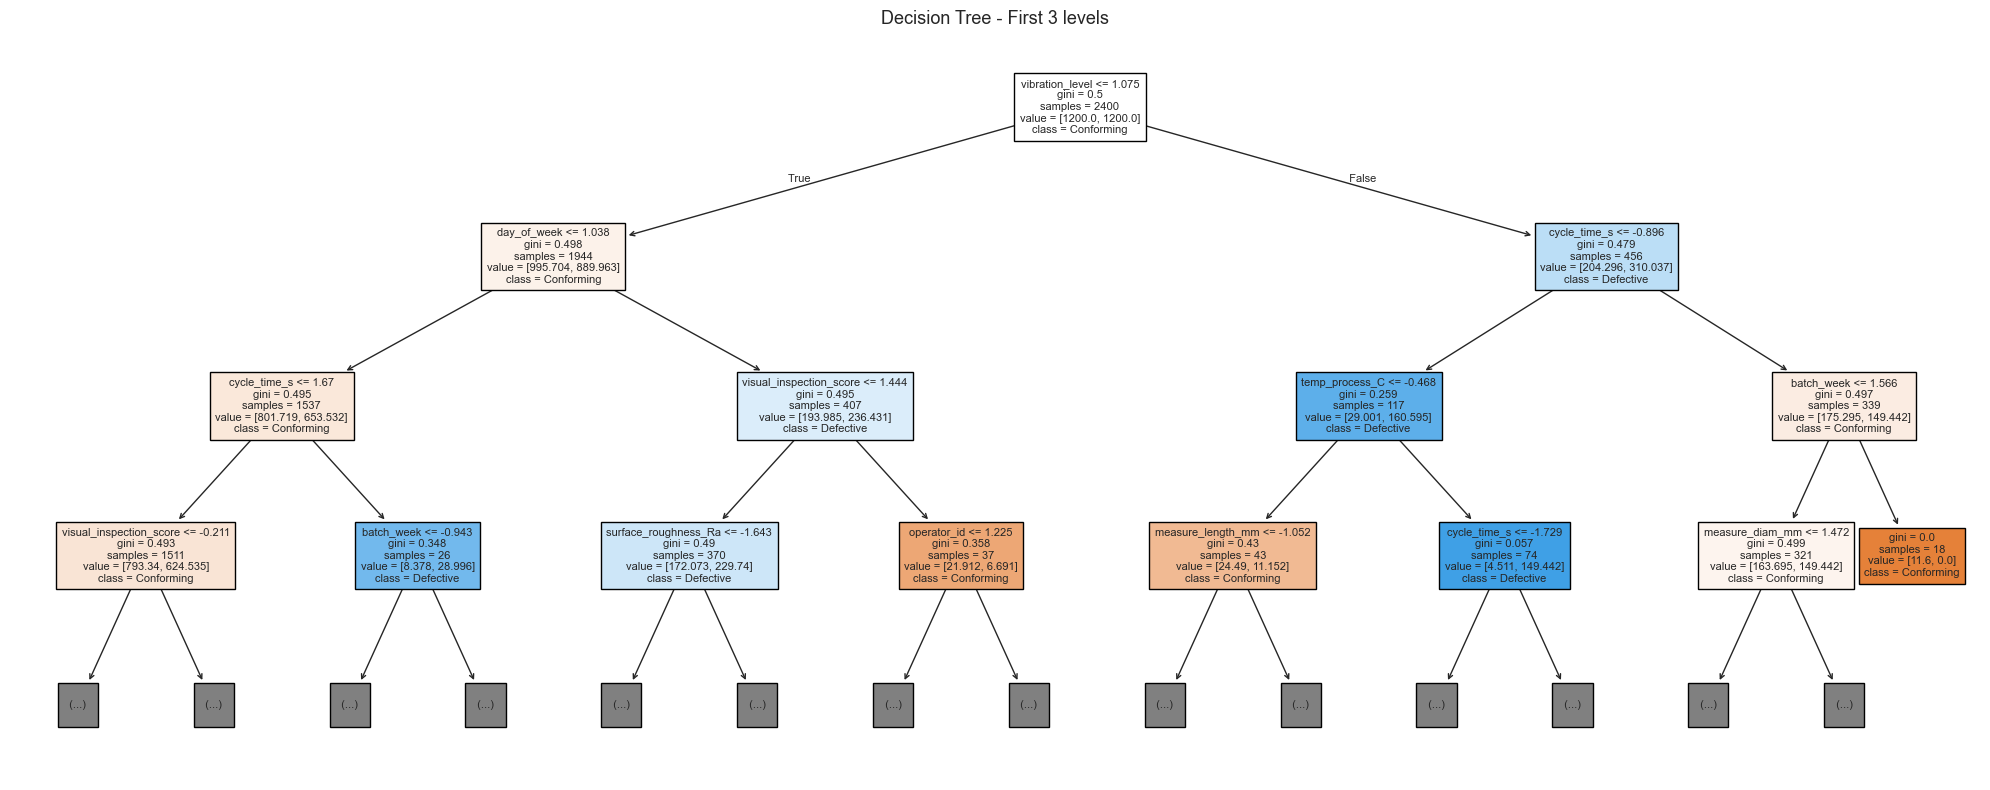

In [19]:
# Graphical visualisation of the first 3 levels (for readability)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_model, feature_names=feature_cols,
          class_names=['Conforming', 'Defective'],
          filled=True, max_depth=3, fontsize=8, ax=ax)
ax.set_title('Decision Tree - First 3 levels', fontsize=13)
plt.tight_layout()
plt.show()

### 6.2 Random Forest

In [20]:
# Random Forest: builds 100 Decision Trees on different subsamples
# and combines their predictions (bagging).
# This reduces variance and overfitting of individual trees.
# n_jobs=-1: uses all available cores to speed up training.

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_proc, y_train)

print('Random Forest trained with 100 trees.')

Random Forest trained with 100 trees.


### 6.3 Logistic Regression

In [21]:
# Logistic Regression: estimates defect probability via a
# linear combination of features passed through the sigmoid function.
# It is the simplest of the three models: useful as a baseline and for interpreting
# the direct impact of each feature (via coefficients).
# REQUIRES scaled features (already done with StandardScaler).

lr_model = LogisticRegression(
    max_iter=1000,           # increased to ensure convergence
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lr_model.fit(X_train_proc, y_train)

print('Logistic Regression trained.')

Logistic Regression trained.


## Section 7 - Performance Evaluation

In [22]:
# Reusable evaluation function

def evaluate_model(model, X_test, y_test, model_name='Model'):
    """Computes and prints the main metrics for a trained model."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # prob. of class 1 (defective)

    print(f'\n{"="*50}')
    print(f'  {model_name}')
    print(f'{"="*50}')
    print(f'Accuracy: {(y_pred==y_test).mean():.4f}')
    print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
    print(f'F1-score (macro): {f1_score(y_test, y_pred, average="macro"):.4f}')
    print(f'F1-score (defective): {f1_score(y_test, y_pred, pos_label=1):.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Conforming', 'Defective']))

    return {
        'Model': model_name,
        'Accuracy': round((y_pred==y_test).mean(), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
        'F1-macro': round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1-defective': round(f1_score(y_test, y_pred, pos_label=1), 4),
        'y_pred': y_pred,
        'y_prob':  y_prob
    }

results_dt = evaluate_model(dt_model, X_test_proc, y_test, 'Decision Tree')
results_rf = evaluate_model(rf_model, X_test_proc, y_test, 'Random Forest')
results_lr = evaluate_model(lr_model, X_test_proc, y_test, 'Logistic Regression')


  Decision Tree
Accuracy: 0.6933
ROC-AUC: 0.5585
F1-score (macro): 0.5508
F1-score (defective): 0.2977

Classification Report:
              precision    recall  f1-score   support

  Conforming       0.80      0.81      0.80       465
   Defective       0.31      0.29      0.30       135

    accuracy                           0.69       600
   macro avg       0.55      0.55      0.55       600
weighted avg       0.69      0.69      0.69       600


  Random Forest
Accuracy: 0.7917
ROC-AUC: 0.5323
F1-score (macro): 0.5420
F1-score (defective): 0.2038

Classification Report:
              precision    recall  f1-score   support

  Conforming       0.79      0.99      0.88       465
   Defective       0.73      0.12      0.20       135

    accuracy                           0.79       600
   macro avg       0.76      0.55      0.54       600
weighted avg       0.78      0.79      0.73       600


  Logistic Regression
Accuracy: 0.5417
ROC-AUC: 0.5516
F1-score (macro): 0.4900
F1-score 

### 7.1 Summary Metrics Table

The most relevant metrics for this problem are ROC-AUC and F1-score on the defective class, which account for both class imbalance and the asymmetric cost of errors.

=== SUMMARY PERFORMANCE TABLE ===
                     Accuracy  ROC-AUC  F1-macro  F1-defective
Model                                                         
Decision Tree          0.6933   0.5585    0.5508        0.2977
Random Forest          0.7917   0.5323    0.5420        0.2038
Logistic Regression    0.5417   0.5516    0.4900        0.3276


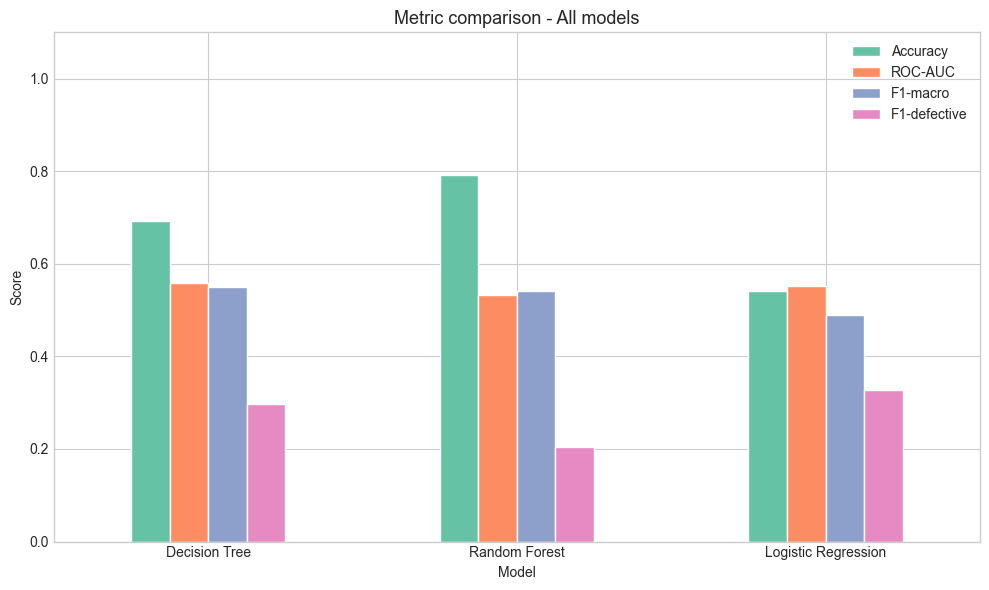

In [23]:
summary_rows = [
    {k: v for k, v in r.items() if k not in ('y_pred', 'y_prob')}
    for r in [results_dt, results_rf, results_lr]
]
summary_df = pd.DataFrame(summary_rows).set_index('Model')

print('=== SUMMARY PERFORMANCE TABLE ===')
print(summary_df.to_string())

summary_df[['Accuracy','ROC-AUC','F1-macro','F1-defective']].plot(
    kind='bar', figsize=(10, 6), rot=0, edgecolor='white'
)
plt.title('Metric comparison - All models', fontsize=13)
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

Results show moderate performance across all three models: ROC-AUC values between 0.53 and 0.56 indicate discriminative power just above a random classifier (0.50). This suggests that the available features, in their current form, do not clearly separate conforming from defective parts.

In terms of ROC-AUC, the Decision Tree is the best model (0.5585), followed by Logistic Regression (0.5516) and Random Forest (0.5323). The Random Forest has the highest absolute accuracy (79.2%), but achieves it by classifying almost everything as conforming: recall on defective parts is only 12%, making it the least useful of the three for the project objective. Logistic Regression, despite the lowest absolute accuracy, achieves the highest recall on defective parts (50%) at the current threshold and is the most balanced model of the three.

### 7.2 ROC Curves

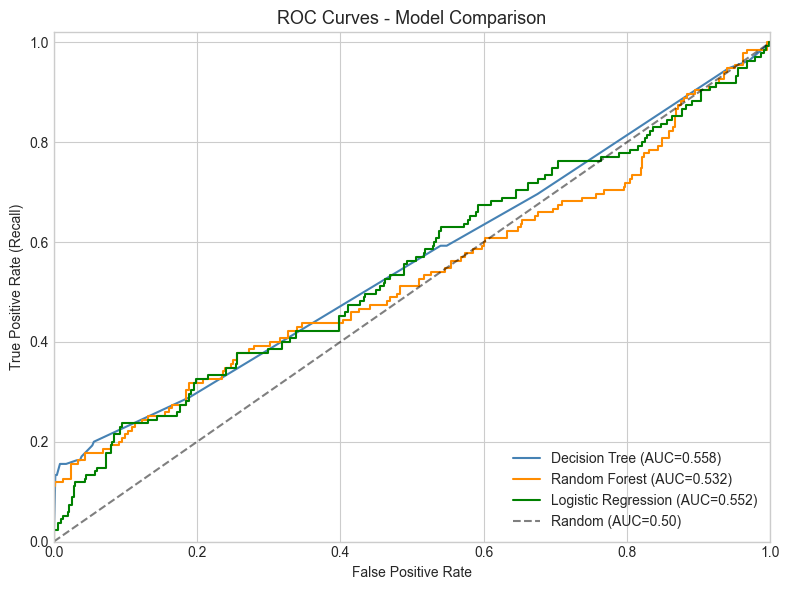

In [24]:
# The ROC curve shows the trade-off between True Positive Rate (recall)
# and False Positive Rate as the classification threshold varies.
# The closer the curve is to the top-left corner, the better the model.
# The dashed line represents a random classifier (AUC=0.5).

fig, ax = plt.subplots(figsize=(8, 6))

for res, color in [(results_dt,'steelblue'), (results_rf,'darkorange'), (results_lr,'green')]:
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, label=f"{res['Model']} (AUC={res['ROC-AUC']:.3f})")

ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Random (AUC=0.50)')
ax.set_title('ROC Curves - Model Comparison', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(loc='lower right')
ax.set_xlim([0,1])
ax.set_ylim([0,1.02])
plt.tight_layout()
plt.show()

### 7.3 Confusion Matrices

Confusion matrices show in detail where each model makes mistakes. The cell at position (Defective, Conforming) represents false negatives: defective parts that the model incorrectly classified as conforming. These are the operationally most critical errors, because the defective part continues on the line undetected and may reach the final assembly or the OEM.

At the default threshold (0.50), the Random Forest misses 119 defective parts out of 135 (88%), the Decision Tree misses 96 out of 135 (71%), and Logistic Regression misses 68 out of 135 (50%). Despite having the lowest absolute accuracy, Logistic Regression detects the most defective parts among the three models.

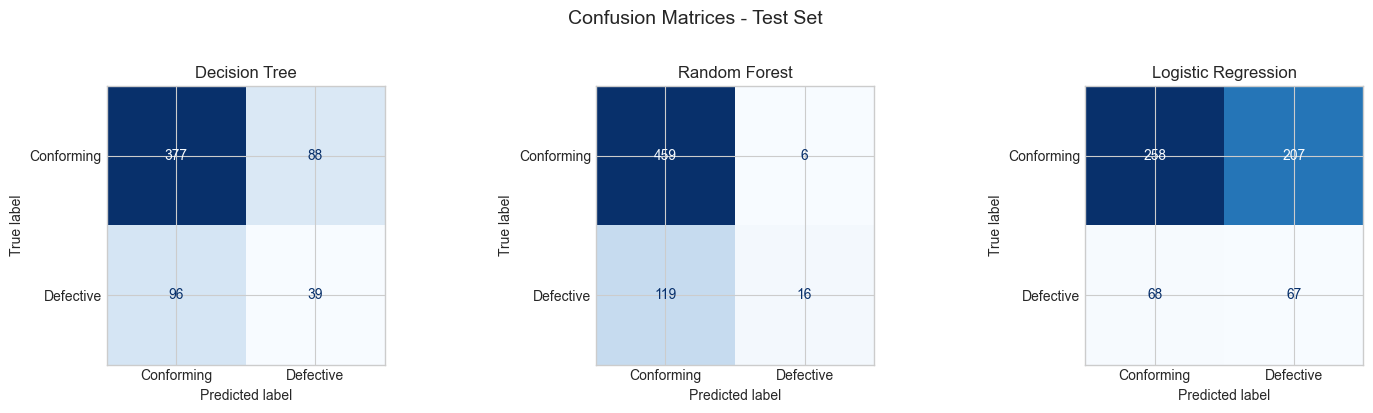


=== False Negatives (undetected defective parts) ===
Decision Tree            : 96 FN out of 135 actual defective parts (71.1% missed)
Random Forest            : 119 FN out of 135 actual defective parts (88.1% missed)
Logistic Regression      : 68 FN out of 135 actual defective parts (50.4% missed)


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for res, title, ax in [
    (results_dt, 'Decision Tree', axes[0]),
    (results_rf, 'Random Forest', axes[1]),
    (results_lr, 'Logistic Regression', axes[2])
]:
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Conforming','Defective']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12)

plt.suptitle('Confusion Matrices - Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('\n=== False Negatives (undetected defective parts) ===')
for res, title, _ in [
    (results_dt,'Decision Tree', None),
    (results_rf,'Random Forest', None),
    (results_lr,'Logistic Regression', None)
]:
    cm = confusion_matrix(y_test, res['y_pred'])
    fn = cm[1,0]
    tot = cm[1,:].sum()
    print(f'{title:25s}: {fn} FN out of {tot} actual defective parts ({fn/tot*100:.1f}% missed)')

### 7.4 Optimal Classification Threshold

The classification threshold determines the probability above which a part is classified as defective. The default threshold of 0.50 does not account for the asymmetric cost of errors: lowering it increases recall (fewer missed defectives) at the cost of more false positives (more conforming parts stopped for inspection). The Precision-Recall curve and the Precision/Recall/F1 comparison across thresholds help identify the best trade-off point.

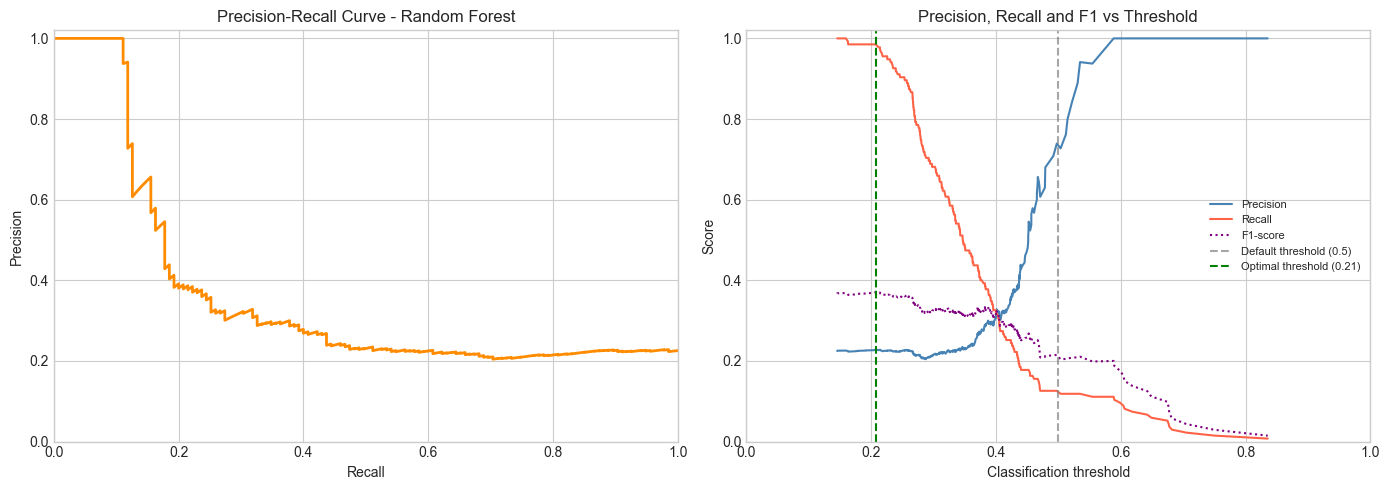

Optimal threshold (max F1): 0.207
Precision: 0.228 | Recall: 0.985 | F1: 0.370


In [26]:
# Default threshold is 0.5: a part with p>=0.5 is classified as defective.
# In production it is worth lowering it to increase recall (fewer missed defects)
# accepting some additional false positives (conforming parts stopped for unnecessary inspection).

y_prob_rf = results_rf['y_prob']
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)

# Find the threshold that maximises the F1-score
f1_scores  = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx   = np.argmax(f1_scores)
best_thr   = thresholds[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions, color='darkorange', linewidth=2)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve - Random Forest', fontsize=12)
axes[0].set_xlim([0,1])
axes[0].set_ylim([0,1.02])

axes[1].plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
axes[1].plot(thresholds, recalls[:-1], label='Recall', color='tomato')
axes[1].plot(thresholds, f1_scores, label='F1-score', color='purple', linestyle=':')
axes[1].axvline(x=0.50, color='gray', linestyle='--', alpha=0.7, label='Default threshold (0.5)')
axes[1].axvline(x=best_thr, color='green', linestyle='--', label=f'Optimal threshold ({best_thr:.2f})')
axes[1].set_xlabel('Classification threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision, Recall and F1 vs Threshold', fontsize=12)
axes[1].legend(fontsize=8)
axes[1].set_xlim([0,1])
axes[1].set_ylim([0,1.02])

plt.tight_layout()
plt.show()

print(f'Optimal threshold (max F1): {best_thr:.3f}')
print(f'Precision: {precisions[best_idx]:.3f} | Recall: {recalls[best_idx]:.3f} | F1: {f1_scores[best_idx]:.3f}')

In [27]:
# Comparison of results with default vs optimal threshold
y_pred_default = (y_prob_rf >= 0.50).astype(int)
y_pred_optimal = (y_prob_rf >= best_thr).astype(int)

print('=== Threshold 0.50 (default) ===')
print(classification_report(y_test, y_pred_default, target_names=['Conforming','Defective']))

print(f'=== Threshold {best_thr:.2f} (optimal F1) ===')
print(classification_report(y_test, y_pred_optimal, target_names=['Conforming','Defective']))

fn_def = confusion_matrix(y_test, y_pred_default)[1,0]
fn_opt = confusion_matrix(y_test, y_pred_optimal)[1,0]
print(f'False negatives at threshold 0.50: {fn_def}')
print(f'False negatives at optimal threshold: {fn_opt}')
print(f'Reduction: {fn_def - fn_opt} additional defective parts detected')

=== Threshold 0.50 (default) ===
              precision    recall  f1-score   support

  Conforming       0.79      0.99      0.88       465
   Defective       0.73      0.12      0.20       135

    accuracy                           0.79       600
   macro avg       0.76      0.55      0.54       600
weighted avg       0.78      0.79      0.73       600

=== Threshold 0.21 (optimal F1) ===
              precision    recall  f1-score   support

  Conforming       0.88      0.03      0.06       465
   Defective       0.23      0.99      0.37       135

    accuracy                           0.25       600
   macro avg       0.56      0.51      0.22       600
weighted avg       0.74      0.25      0.13       600

False negatives at threshold 0.50: 119
False negatives at optimal threshold: 2
Reduction: 117 additional defective parts detected


The optimal threshold for the Random Forest is well below the default of 0.50 (around 0.21-0.22 depending on the run). This behaviour is indicative of a model that assigns low probabilities to defective parts, because the features do not provide sufficiently strong signals: the model rarely exceeds 30% estimated probability even for actually defective parts. Lowering the threshold catches almost all defective parts (few FN), but in exchange classifies approximately 95% of conforming parts as defective: in production, this would mean sending nearly all parts to manual inspection, making the system unusable. This shows that threshold tuning cannot fully compensate for a model with low discriminative power: better signals in the features are needed, not just a lower threshold.

### 7.5 Cross-Validation - Model Stability

5-fold cross-validation measures how stable results are as the validation subset changes. The dataset is divided into 5 parts: at each iteration 4 are used for training and 1 for validation, then the 5 scores are averaged. Low variance across folds indicates that performance estimates are reliable and do not depend on a particular data partition.

5-fold cross-validation (ROC-AUC):

Decision Tree            : 0.5563 +/- 0.0312  (folds: [np.float64(0.596), np.float64(0.585), np.float64(0.546), np.float64(0.509), np.float64(0.545)])
Random Forest            : 0.5550 +/- 0.0155  (folds: [np.float64(0.556), np.float64(0.585), np.float64(0.544), np.float64(0.545), np.float64(0.546)])
Logistic Regression      : 0.5548 +/- 0.0135  (folds: [np.float64(0.562), np.float64(0.577), np.float64(0.55), np.float64(0.536), np.float64(0.55)])


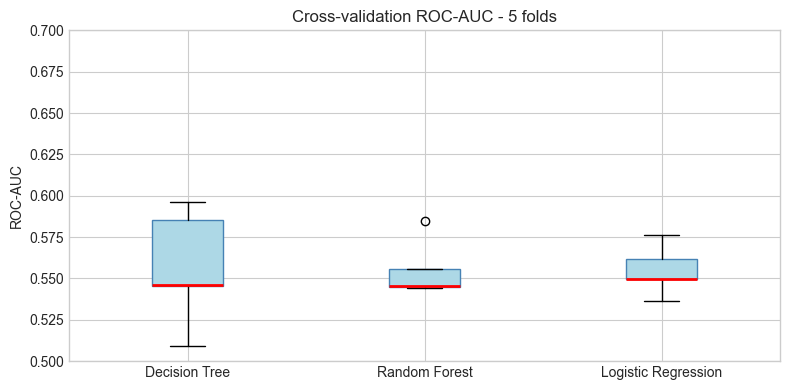

In [28]:
# Cross-validation is run on the entire dataset using the pipeline
# already fitted on the training set (transform, not fit_transform), to avoid
# data leakage. Models are instantiated from scratch at each fold.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_all_proc = numeric_pipeline.transform(X)  # uses the pipeline already fitted on X_train

print('5-fold cross-validation (ROC-AUC):\n')
cv_results = {}

models_cv = [
    (DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=RANDOM_STATE), 'Decision Tree'),
    (RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced',
                             random_state=RANDOM_STATE, n_jobs=-1), 'Random Forest'),
    (LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE), 'Logistic Regression')
]

for model, name in models_cv:
    scores = cross_val_score(model, X_all_proc, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s}: {scores.mean():.4f} +/- {scores.std():.4f}  '
          f'(folds: {[round(s,3) for s in scores]})')

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Cross-validation ROC-AUC - 5 folds', fontsize=12)
ax.set_ylabel('ROC-AUC')
ax.set_ylim([0.5, 0.7])
plt.tight_layout()
plt.show()

Cross-validation confirms the results already observed on the test set: all three models settle on ROC-AUC values between 0.53 and 0.57, with a low standard deviation indicating good stability. The consistency between the single test set evaluation and cross-validation rules out significant overfitting. The main limitation is not the model's generalization, but the discriminative power of the available features relative to the target variable.

## Section 8 - Interpretability: Feature Importance

Understanding which variables drive predictions has direct practical value: it allows process engineers to focus preventive checks on the most critical measurements and to intervene on root causes of defects. With models whose ROC-AUC is modest, as in this case, importance rankings should be read as directional indications, not as definitive conclusions.

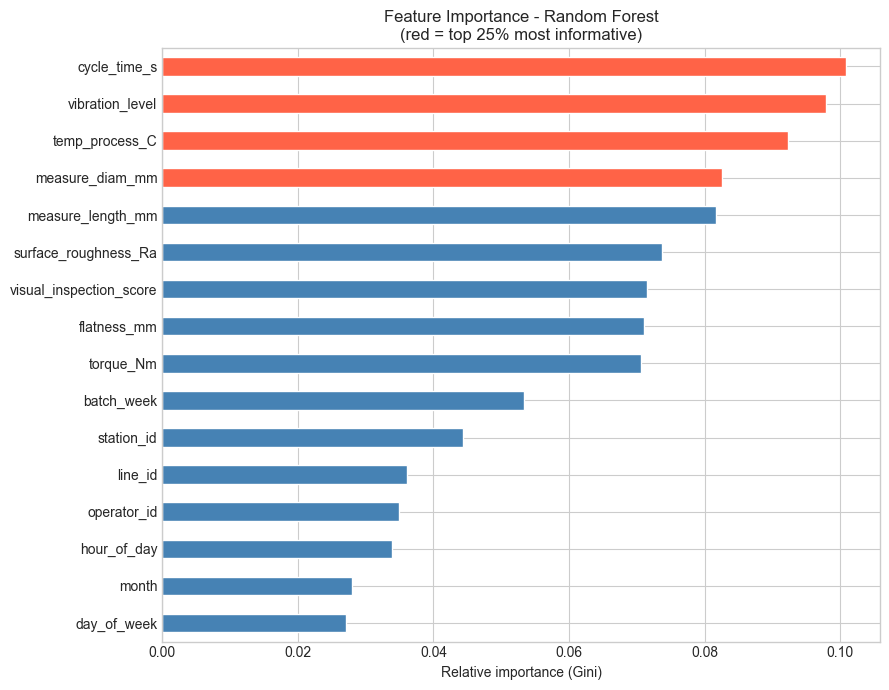

Top 5 features (Random Forest):
cycle_time_s         0.1009
vibration_level      0.0980
temp_process_C       0.0923
measure_diam_mm      0.0826
measure_length_mm    0.0817
dtype: float64


In [29]:
# Random Forest feature importance
# Importance = mean reduction in Gini impurity produced by that feature
# across all 100 trees. Higher values = more discriminating feature.

fi = pd.Series(rf_model.feature_importances_, index=feature_cols)
fi_sorted = fi.sort_values(ascending=True)
thr75 = fi_sorted.quantile(0.75)
colors = ['tomato' if v >= thr75 else 'steelblue' for v in fi_sorted]

fig, ax = plt.subplots(figsize=(9, 7))
fi_sorted.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance - Random Forest\n(red = top 25% most informative)', fontsize=12)
ax.set_xlabel('Relative importance (Gini)')
plt.tight_layout()
plt.show()

print('Top 5 features (Random Forest):')
print(fi.sort_values(ascending=False).head(5).round(4))

Feature importance is distributed very uniformly: the top nine variables all carry weights between 7% and 10%, with no single dominant signal. At the top are `cycle_time_s` (10.1%), `vibration_level` (9.8%) and `temp_process_C` (9.2%), consistent with observations from the boxplots and correlations. The absence of a clearly dominant feature further confirms that the model cannot identify a strong signal and distributes weight almost uniformly. From an operational perspective, the top three features are the most interesting to monitor: a low cycle time, high vibration, and high temperature are process conditions that warrant closer attention on the production line.

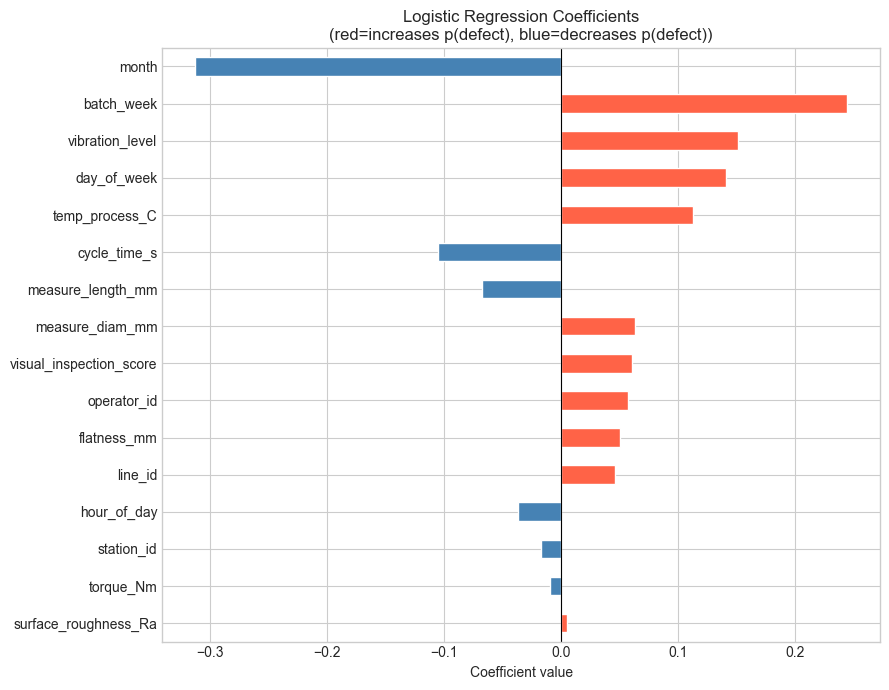

Top 5 features (Logistic Regression, absolute value):
month              0.3132
batch_week         0.2444
vibration_level    0.1510
day_of_week        0.1403
temp_process_C     0.1123
dtype: float64


In [30]:
# Logistic Regression coefficients
# After scaling, coefficients are comparable to each other.
# Positive = increases defect probability; negative = decreases it.

lr_coefs = pd.Series(lr_model.coef_[0], index=feature_cols)
lr_sorted = lr_coefs.reindex(lr_coefs.abs().sort_values(ascending=True).index)
colors_lr = ['tomato' if v > 0 else 'steelblue' for v in lr_sorted]

fig, ax = plt.subplots(figsize=(9, 7))
lr_sorted.plot(kind='barh', ax=ax, color=colors_lr, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(red=increases p(defect), blue=decreases p(defect))',
             fontsize=12)
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

print('Top 5 features (Logistic Regression, absolute value):')
print(lr_coefs.abs().sort_values(ascending=False).head(5).round(4))

Logistic Regression assigns the highest weights to temporal features: `month` (coeff. -0.31) and `batch_week` (+0.24) are the most influential variables, with values noticeably higher than the physical measurements. The negative sign of `month` indicates that later months of the year are associated with a lower probability of defect (possible production seasonality). A positive `batch_week` indicates that batches from later weeks in the year correlate with more defects. Among physical measurements, `vibration_level` and `temp_process_C` have positive coefficients (increasing defect probability), consistent with previous findings. The high weight on temporal features may reflect spurious correlations in the training data that do not generalise over time; this should be actively monitored if the model were to be deployed in production.

## Section 9 - Operational Cost Analysis

Each classification error has a different cost for AutomaParts. A false negative (undetected defective part) has a much higher cost than a false positive (conforming part unnecessarily stopped), because in the former case the defective part can reach the assembly line or the OEM. The values used here are indicative and should be calibrated with actual company costs. This analysis translates machine learning metrics into concrete economic impact, to support the choice of optimal threshold.

In [31]:
# Indicative values — AutomaParts should calibrate them with actual costs.
COST_FN = 500  # EUR: defective part reaching the OEM (recall, penalty, rework)
COST_FP = 25   # EUR: conforming part unnecessarily blocked (extra inspection, delay)

print('=== Operational cost analysis ===')
print(f'FN cost: EUR {COST_FN} | FP cost: EUR {COST_FP}\n')

for res, title in [(results_dt,'Decision Tree'),(results_rf,'Random Forest'),(results_lr,'Logistic Regression')]:
    cm = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    cost = fn * COST_FN + fp * COST_FP
    print(f'{title:25s} | FN: {fn:3d} | FP: {fp:3d} | Estimated cost: EUR {cost:,.0f}')

cm_opt = confusion_matrix(y_test, y_pred_optimal)
tn, fp, fn, tp = cm_opt.ravel()
cost_opt = fn * COST_FN + fp * COST_FP
print(f'\nRF threshold {best_thr:.2f} (optimal) | FN: {fn:3d} | FP: {fp:3d} | Estimated cost: EUR {cost_opt:,.0f}')

=== Operational cost analysis ===
FN cost: EUR 500 | FP cost: EUR 25

Decision Tree             | FN:  96 | FP:  88 | Estimated cost: EUR 50,200
Random Forest             | FN: 119 | FP:   6 | Estimated cost: EUR 59,650
Logistic Regression       | FN:  68 | FP: 207 | Estimated cost: EUR 39,175

RF threshold 0.21 (optimal) | FN:   2 | FP: 450 | Estimated cost: EUR 12,250


Translated into economic terms, the difference between the models is clear: Logistic Regression at the default threshold is the least costly among the standard configurations (EUR 39,175), because it has the fewest false negatives (68) despite having more false positives (207). The Random Forest with threshold 0.21 achieves the lowest estimated cost (EUR 12,250), but at the expense of 450 additional inspections on conforming parts — a hidden operational cost not reflected in the EUR 12,250 figure, but which in terms of machine time and human resources would be unsustainable. An intermediate threshold value, calibrated against actual AutomaParts production volumes and costs, is the correct direction.

## Section 10 - Summary

In [32]:
print('=' * 60)
print('FINAL TABLE - TEST SET PERFORMANCE')
print('=' * 60)
print(summary_df.to_string())
print('=' * 60)

best_model = summary_df['ROC-AUC'].idxmax()
print(f'\nRecommended model: {best_model}')
print(f'ROC-AUC: {summary_df.loc[best_model, "ROC-AUC"]}')
print(f'Recommended threshold: {best_thr:.2f} (optimised on F1)')

FINAL TABLE - TEST SET PERFORMANCE
                     Accuracy  ROC-AUC  F1-macro  F1-defective
Model                                                         
Decision Tree          0.6933   0.5585    0.5508        0.2977
Random Forest          0.7917   0.5323    0.5420        0.2038
Logistic Regression    0.5417   0.5516    0.4900        0.3276

Recommended model: Decision Tree
ROC-AUC: 0.5585
Recommended threshold: 0.21 (optimised on F1)


# Conclusions

## Results Obtained

The three trained models show moderate performance on the test set, with ROC-AUC between 0.53 and 0.56, just above the level of a random classifier (0.50). 5-fold cross-validation confirms the stability of these values, ruling out significant overfitting. The main limitation is the discriminative power of the available features: in their current form they do not allow the models to clearly separate conforming parts from defective ones.

In terms of ROC-AUC, the Decision Tree is the best model (0.5585), followed by Logistic Regression (0.5516) and Random Forest (0.5323). However, the Random Forest has the highest absolute accuracy (79.2%), which it achieves by classifying almost everything as conforming: recall on defective parts is only 12%, making it the least useful of the three for the project objective. Logistic Regression, with the lowest absolute accuracy, achieves the highest recall on defective parts at threshold 0.50 (50%) and is the most balanced model. If one model had to be selected in the current configuration, Logistic Regression would be the preferred choice.

## False Negatives and Cost Analysis

False negatives (defective parts classified as conforming) are the most critical operational risk. Using the indicative costs in the analysis (EUR 500 per false negative, EUR 25 per false positive), Logistic Regression at threshold 0.50 produces the lowest estimated cost among the three standard models.

Lowering the Random Forest threshold to 0.21 (optimal for F1-score), false negatives drop from 119 to 2, but false positives rise to 450 out of 465 conforming parts: in practice the model stops nearly everything, which would make it unusable in production. This highlights how threshold tuning must find a sustainable trade-off, calibrated against actual company costs.

## Most Informative Features

The most discriminating variables according to the Random Forest are the dimensional and process variables. This is consistent with the operational context: out-of-tolerance measurements and abnormal process conditions are the typical causes of defects. The engineering team can use these results to focus preventive controls on the highest-impact variables, even though with ROC-AUC close to 0.55 these rankings should be interpreted as directional indications.

## Recommendations

The current level of performance is not sufficient for autonomous deployment on the production line. The models may nonetheless be useful as a first filter to direct parts toward different inspection levels:

| Probability `p` | Suggested Action |
|---|---|
| `p < 0.20` | conforming - proceed on line |
| `0.20 <= p < 0.50` | grey zone - additional manual inspection |
| `p >= 0.50` | likely defective - reject or 100% inspection |

Thresholds should be calibrated with actual AutomaParts costs, which in practice may differ significantly from the indicative values used in this analysis.

To improve performance in a second phase, it is recommended to:

- collect more historical data (6-12 months) to obtain a more representative sample of different operating conditions
- add features related to machine state (hours since last maintenance, tool age), which are often among the direct causes of defects
- evaluate boosting-based algorithms (XGBoost, LightGBM) which often perform better on tabular datasets of this type
- define with the operations team the actual costs of false negatives and false positives to calibrate the threshold precisely